In [1]:
# скачиваем датасет
%pip install medmnist --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install tqdm matplotlib scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


# MedMNIST unsupervised

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from medmnist import PathMNIST
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Загрузка данных с RGB каналами
dataset = PathMNIST(split='test', download=True, size=28, as_rgb=True)  # as_rgb=True -> 3 канала
images = dataset.imgs  # (N, 28, 28, 3)
labels = dataset.labels.flatten()

# Преобразуем в 2D массив: (N, 28*28*3) = (N, 2352)
N = len(images)
X = images.reshape(N, -1)  # (N, 2352) - правильно!

print(f"Размерность данных: {X.shape}")
print(f"Количество классов: {len(np.unique(labels))}")
print(f"Размер одного изображения: {images.shape[1:]}")

Размерность данных: (7180, 2352)
Количество классов: 9
Размер одного изображения: (28, 28, 3)


In [17]:
# ============================================================
# K-Means кластеризация
# ============================================================
n_clusters = 9
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Метрики
ari = adjusted_rand_score(labels, cluster_labels)
nmi = normalized_mutual_info_score(labels, cluster_labels)

# Silhouette на подвыборке (иначе долго)
sample_size = min(5000, N)
silhouette = silhouette_score(X[:sample_size], cluster_labels[:sample_size])
print(f"\n=== Метрики K-Means ===")
print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Info (NMI): {nmi:.3f}")
print(f"Silhouette Score: {silhouette:.3f}")



=== Метрики K-Means ===
Adjusted Rand Index (ARI): 0.306
Normalized Mutual Info (NMI): 0.454
Silhouette Score: 0.108



Выполняется PCA для уменьшения размерности...
Выполняется t-SNE (может занять минуту)...


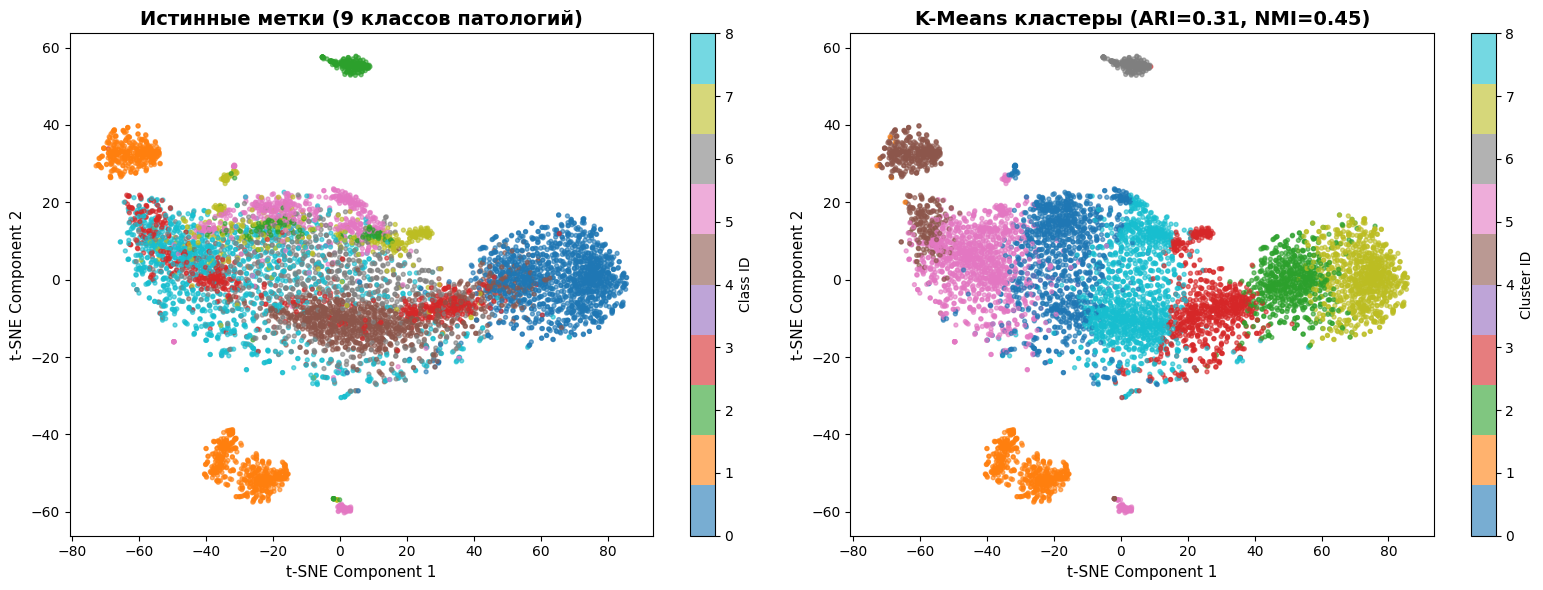

In [18]:
# ============================================================
# ВИЗУАЛИЗАЦИЯ 1: t-SNE
# ============================================================
print("\nВыполняется PCA для уменьшения размерности...")
pca_init = PCA(n_components=50)
X_pca = pca_init.fit_transform(X)

print("Выполняется t-SNE (может занять минуту)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne = tsne.fit_transform(X_pca[:, :30])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=8, alpha=0.6)
axes[0].set_title('Истинные метки (9 классов патологий)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE Component 1', fontsize=11)
axes[0].set_ylabel('t-SNE Component 2', fontsize=11)
plt.colorbar(scatter1, ax=axes[0], ticks=range(9), label='Class ID')

scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='tab10', s=8, alpha=0.6)
axes[1].set_title(f'K-Means кластеры (ARI={ari:.2f}, NMI={nmi:.2f})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Component 1', fontsize=11)
axes[1].set_ylabel('t-SNE Component 2', fontsize=11)
plt.colorbar(scatter2, ax=axes[1], ticks=range(n_clusters), label='Cluster ID')

plt.tight_layout()
plt.savefig('1_tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

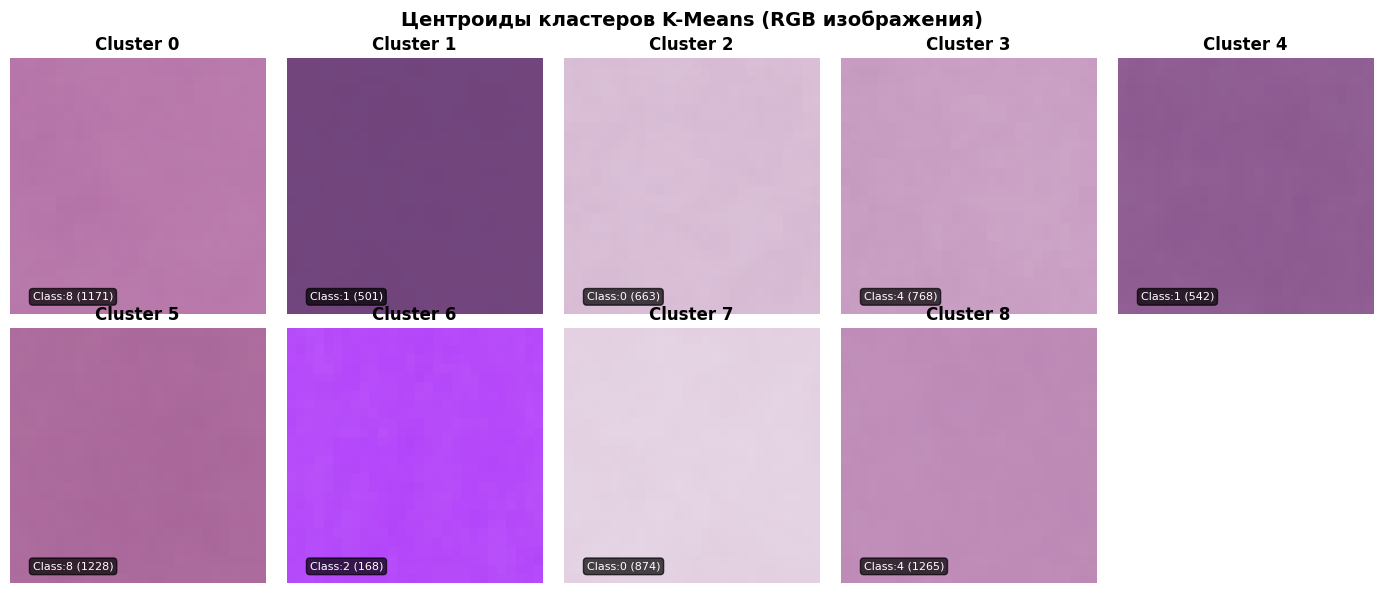

In [19]:
# ============================================================
# ВИЗУАЛИЗАЦИЯ 2: Центроиды кластеров (для RGB изображений)
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(n_clusters):
    centroid = kmeans.cluster_centers_[i].reshape(28, 28, 3)  # (28,28,3) для RGB
    centroid = centroid.astype(np.uint8)  # конвертируем в целые для отображения
    axes[i].imshow(centroid)  # без cmap='gray' для цветных изображений
    axes[i].set_title(f'Cluster {i}', fontsize=12, fontweight='bold')
    axes[i].axis('off')
    
    # Добавляем информацию о доминирующем классе
    mask = cluster_labels == i
    if mask.sum() > 0:
        dominant = np.bincount(labels[mask]).argmax()
        count = mask.sum()
        axes[i].text(2, 26, f'Class:{dominant} ({count})', fontsize=8, color='white',
                    bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

for i in range(n_clusters, len(axes)):
    axes[i].axis('off')

plt.suptitle('Центроиды кластеров K-Means (RGB изображения)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('2_centroids.png', dpi=150, bbox_inches='tight')
plt.show()

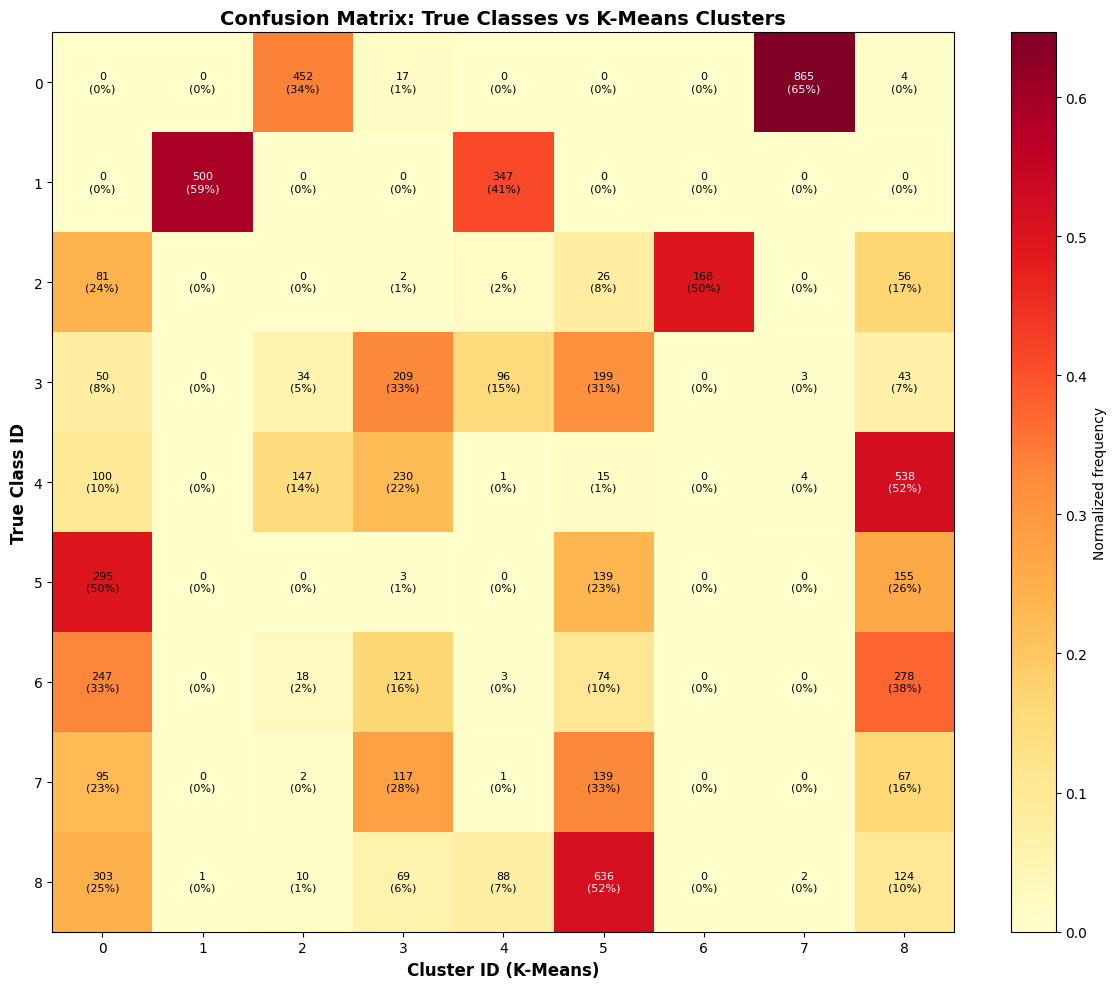

In [20]:
# ============================================================
# ВИЗУАЛИЗАЦИЯ 3: Матрица путаницы
# ============================================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, cluster_labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_normalized, cmap='YlOrRd', interpolation='nearest', aspect='auto')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = ax.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]*100:.0f}%)',
                      ha="center", va="center", color="white" if cm_normalized[i, j] > 0.5 else "black",
                      fontsize=8)

ax.set_xlabel('Cluster ID (K-Means)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class ID', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix: True Classes vs K-Means Clusters', fontsize=14, fontweight='bold')
ax.set_xticks(range(n_clusters))
ax.set_yticks(range(len(np.unique(labels))))

plt.colorbar(im, ax=ax, label='Normalized frequency')
plt.tight_layout()
plt.savefig('3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

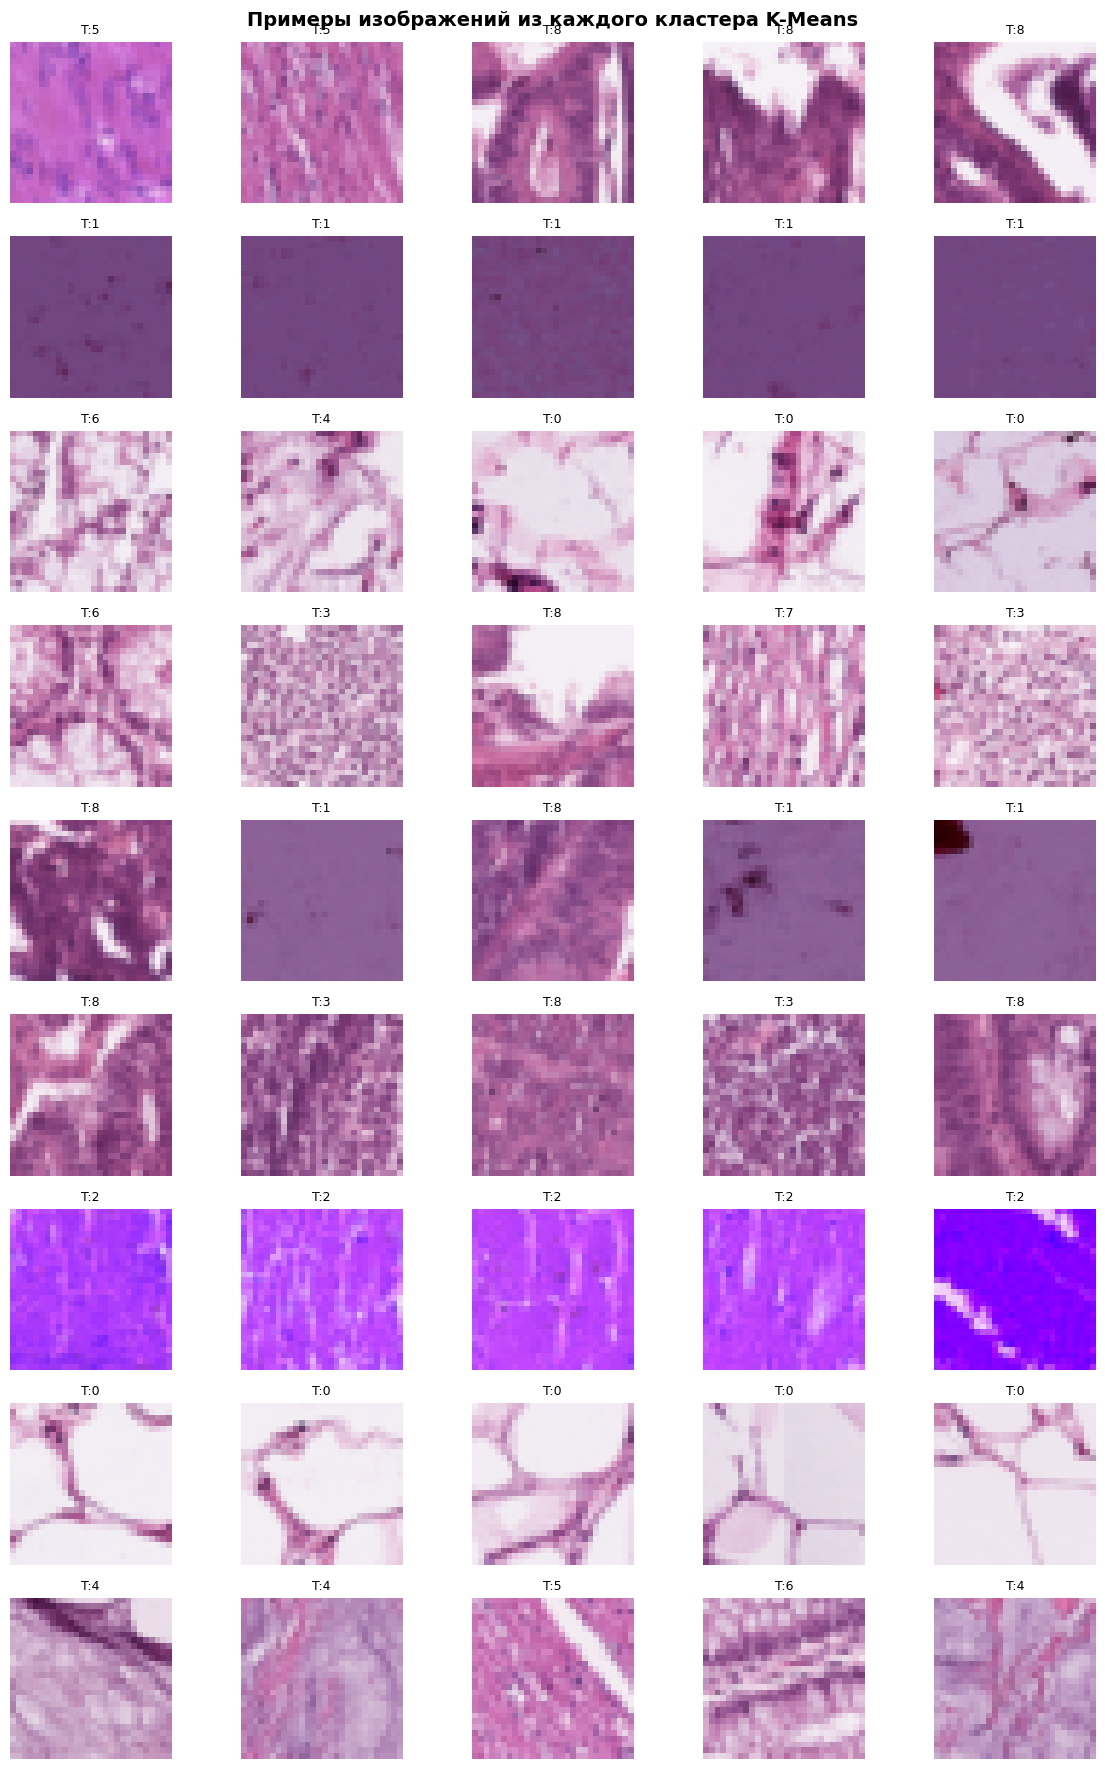

In [21]:
# ============================================================
# ВИЗУАЛИЗАЦИЯ 4: Примеры изображений из каждого кластера
# ============================================================
fig, axes = plt.subplots(n_clusters, 5, figsize=(12, 2*n_clusters))

for cluster_id in range(n_clusters):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    
    if len(cluster_indices) == 0:
        for j in range(5):
            axes[cluster_id, j].axis('off')
        continue
    
    sample_indices = np.random.choice(cluster_indices, size=min(5, len(cluster_indices)), replace=False)
    
    for j, idx in enumerate(sample_indices):
        img = images[idx]  # уже (28,28,3)
        true_label = labels[idx]
        axes[cluster_id, j].imshow(img)
        axes[cluster_id, j].set_title(f'T:{true_label}', fontsize=9)
        axes[cluster_id, j].axis('off')
    
    for j in range(len(sample_indices), 5):
        axes[cluster_id, j].axis('off')
    
    axes[cluster_id, 0].set_ylabel(f'Cluster {cluster_id}', fontsize=11, fontweight='bold', rotation=0, labelpad=30)

plt.suptitle('Примеры изображений из каждого кластера K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('4_cluster_examples.png', dpi=150, bbox_inches='tight')
plt.show()

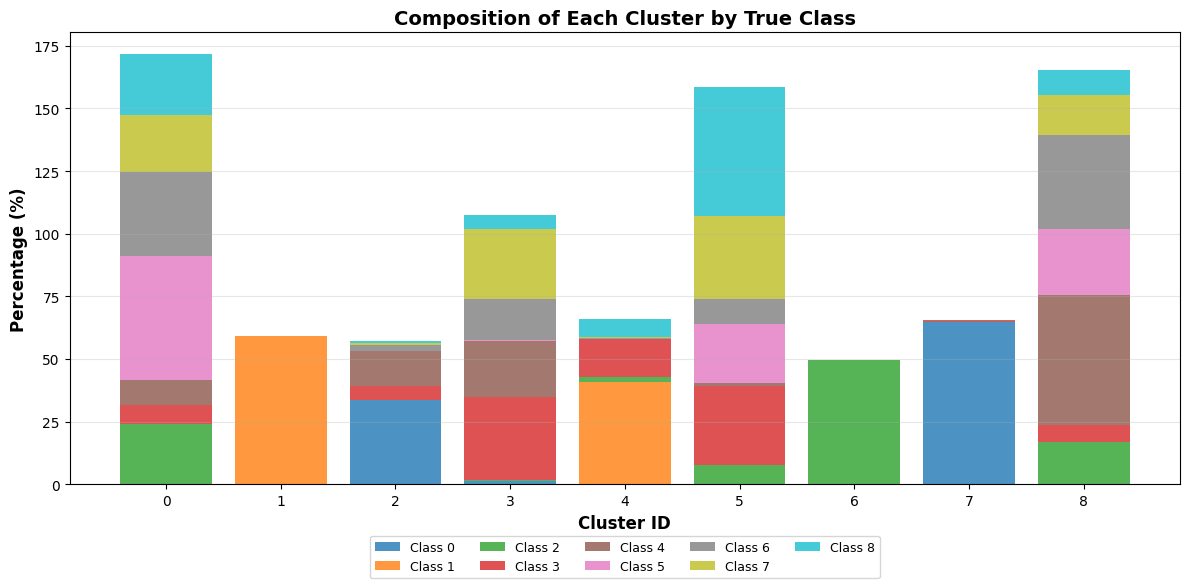

In [22]:
# ============================================================
# ВИЗУАЛИЗАЦИЯ 6: Распределение кластеров
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

cluster_distribution = []
for true_class in range(len(np.unique(labels))):
    mask = labels == true_class
    cluster_counts = np.bincount(cluster_labels[mask], minlength=n_clusters)
    cluster_distribution.append(cluster_counts)

cluster_distribution = np.array(cluster_distribution)
cluster_percentages = cluster_distribution / cluster_distribution.sum(axis=1, keepdims=True) * 100

bottom = np.zeros(n_clusters)
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for true_class in range(cluster_percentages.shape[0]):
    ax.bar(range(n_clusters), cluster_percentages[true_class], bottom=bottom, 
           label=f'Class {true_class}', color=colors[true_class], alpha=0.8)
    bottom += cluster_percentages[true_class]

ax.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Composition of Each Cluster by True Class', fontsize=14, fontweight='bold')
ax.set_xticks(range(n_clusters))
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('6_cluster_composition.png', dpi=150, bbox_inches='tight')
plt.show()